## Bristle Connectivity

In this notebook we quantify the downstream connectivity of bristle axons from the front left leg. 

In [1]:
from caveclient import CAVEclient
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import matplotlib

In [2]:
#Anterior Posterior Palette
ap_palette = sns.color_palette("ch:s=.25,rot=-.25",2).as_hex()

#Dorsal Ventral Palette
dv_palette = sns.cubehelix_palette(reverse=True, as_cmap=True)

#Proximal Distal Palette
pd_palette = sns.cubehelix_palette(start=2, rot=0, dark=0.1, light=.9, reverse=True, as_cmap=True)


### Input vs Output Counts

Reading in important data metrics including a precomputed synapse table and the total input and ouput counts from the client.

In [3]:
dataset = 'fanc_production_mar2021'
client = CAVEclient(dataset)

syn_df = pd.read_pickle('../data/bristle_downstream_synapses_1125.pkl')
bristle_ids = syn_df.pre_pt_root_id.unique().tolist()

In [4]:
#Querying overall input and output counts - This may take a minute or two
synapse_in_counts = client.materialize.query_view('synapse_in_counts', filter_in_dict={'root_id': bristle_ids})
synapse_out_counts = client.materialize.query_view('synapse_out_counts', filter_in_dict={'root_id': bristle_ids})

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [5]:
#Reformatting the synapse table to have a bristle table (each row is one bristle) with the synapse counts merged in
bristle_df = syn_df.drop_duplicates('pre_pt_root_id')[['pre_pt_root_id','bristle_ap_binary','bristle_dv_avg','bristle_pd_avg']]
bristle_df = bristle_df.merge(synapse_in_counts[['n_input','root_id']], how ='left',
                                        right_on = 'root_id', left_on='pre_pt_root_id')

bristle_df = bristle_df.merge(synapse_out_counts[['n_output','root_id']], how ='left',
                                        right_on = 'root_id', left_on='pre_pt_root_id')


### Do Spatial Axes impact synaptic output

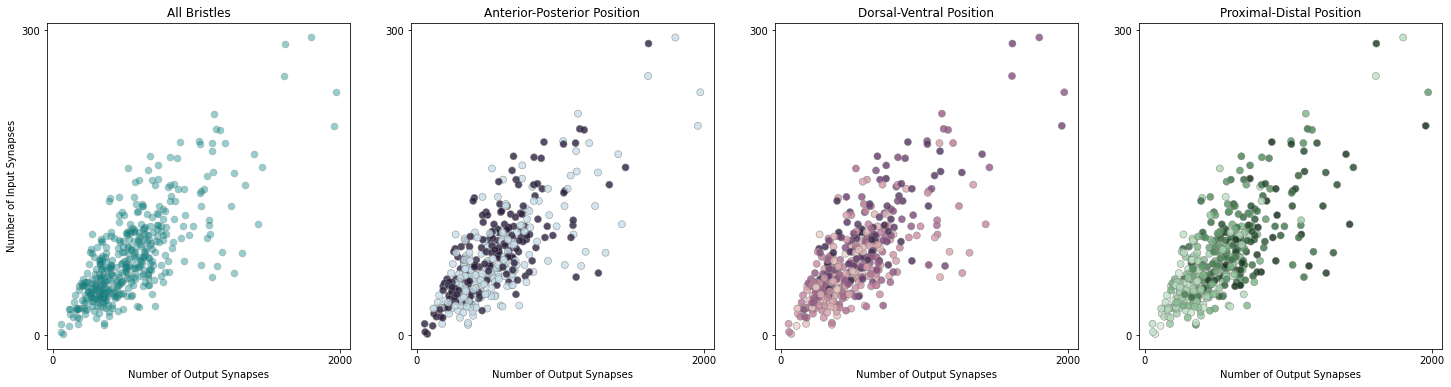

In [6]:
fig, ax = plt.subplots(1,4,figsize=(25,6))

sns.scatterplot(x='n_output',y='n_input',color='teal',
                 data = bristle_df,alpha=0.4,s=50,edgecolor='gray', ax =ax[0],
                 legend = False)

sns.scatterplot(x='n_output',y='n_input',hue='bristle_ap_binary',palette = ap_palette,
                 data = bristle_df,alpha=0.8,s=50,edgecolor='gray', ax =ax[1],
                 legend = False)

sns.scatterplot(x='n_output',y='n_input',hue='bristle_dv_avg',palette=dv_palette,
                 data = bristle_df,alpha=0.8,s=50,edgecolor='gray', ax =ax[2],
                 legend = False)

sns.scatterplot(x='n_output',y='n_input',hue='bristle_pd_avg',palette=pd_palette,
                 data = bristle_df,alpha=0.8,s=50,edgecolor='gray', ax =ax[3],
                 legend = False)

ax[0].set_title('All Bristles')
ax[1].set_title('Anterior-Posterior Position')
ax[2].set_title('Dorsal-Ventral Position')
ax[3].set_title('Proximal-Distal Position')

for i in range(4):
    ax[i].set_ylabel('Number of Input Synapses')
    if i > 0:
        ax[i].set_ylabel('')
    ax[i].set_yticks([0,300])
    ax[i].set_xticks([0,2000])
    ax[i].set_xlabel('Number of Output Synapses')

plt.show()

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
### Ant. / Post
# Remove rows with NA values
bristle_df = bristle_df.dropna()

y = bristle_df.bristle_ap_binary.to_numpy()
x = bristle_df.n_output.to_numpy().reshape(-1, 1)
apmodel = LinearRegression()
apmodel.fit(x,y)

r_sq = apmodel.score(x,y)
print(f"coefficient of determination for Ant/Post: {r_sq}")


### Dors. / Vent

y = bristle_df.bristle_dv_avg.to_numpy()
x = bristle_df.n_output.to_numpy().reshape(-1, 1)
apmodel = LinearRegression()
apmodel.fit(x,y)

r_sq = apmodel.score(x,y)
print(f"coefficient of determination for Dors/Vent: {r_sq}")


### Prox. / Dist.

y = bristle_df.bristle_pd_avg.to_numpy()
x = bristle_df.n_output.to_numpy().reshape(-1, 1)
x = bristle_df[['n_output','n_input']].to_numpy()
apmodel = LinearRegression()
apmodel.fit(x,y)

r_sq = apmodel.score(x,y)
print(f"coefficient of determination for Prox/Dist: {r_sq}")


coefficient of determination for Ant/Post: 8.237914741471286e-07
coefficient of determination for Dors/Vent: 0.05122347089790513
coefficient of determination for Prox/Dist: 0.30409416786540333


## Downstream Connectivity

In [9]:
#Instead of the synapse df, this is an edge df where each row is a connection from a bristle to a downstream partner 
# and the number of synapses in that connection is in the 'synapse_count' column
edge_df = pd.read_pickle('../data/bristle_downstream_connectivity_1125.pkl')

In [10]:
#Calculating the proportion output of each connection for each bristle
unstacked = edge_df.groupby(['pre_pt_root_id','post_classification_system'])['synapse_count'].sum().unstack()
unstacked = unstacked.fillna(0)

fract_unstacked = unstacked.div(unstacked.sum(axis=1), axis=0)
fract_unstacked.melt()

,post_classification_system,value
0,ascending,0.281250
1,ascending,0.116000
2,ascending,0.200000
3,ascending,0.676471
4,ascending,0.000000
...,...,...
2485,sensory,0.000000
2486,sensory,0.000000
2487,sensory,0.000000
2488,sensory,0.000000


Across the population of bristle axons, let's plot the proportion output onto the different cell classes: Ascending, Descending, Intersegmental, Local, Sensory, and Motor neurons

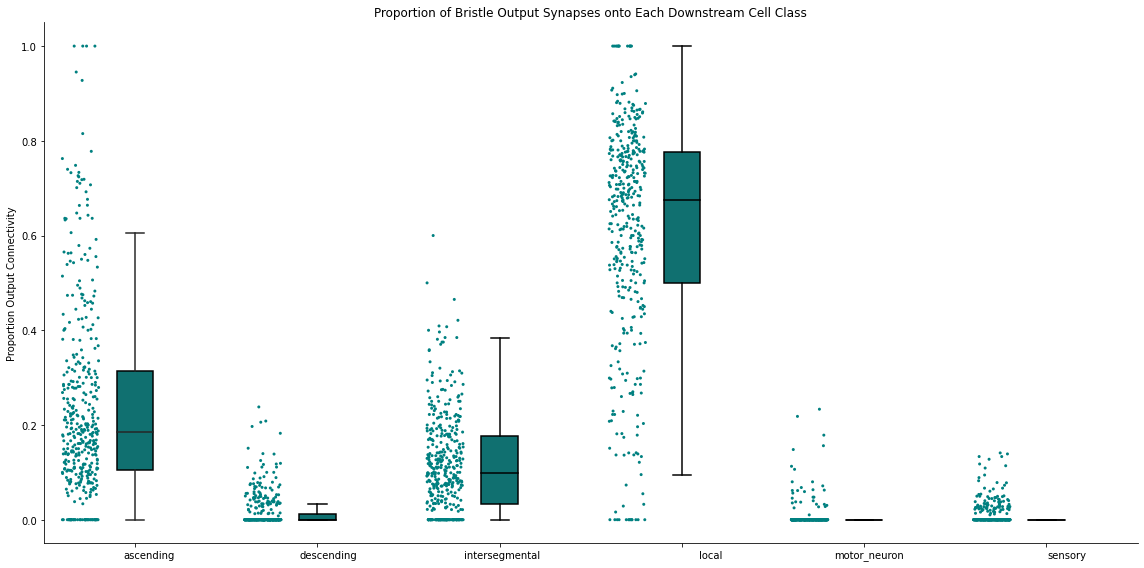

In [11]:
def change_width(ax, new_value):
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - new_value

        # change patch width
        patch.set_width(new_value)

        # re-center patch
        patch.set_x(patch.get_x() + diff * .5)
        
boxplot_width = .2 # thinner to make room for having swarmplot beside
stripplot_offset = -.3 # offset to left of boxplot
xlim_offset = -1 # necessary to show leftmost swarmplot  

#sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(1,figsize=(16,8))

sns.stripplot(x='post_classification_system', y='value',color='teal', s=3,
                data = fract_unstacked.melt(), ax=ax)

path_collections = [child for child in ax.get_children() 
                    if isinstance(child,matplotlib.collections.PathCollection)] 

for path_collection in path_collections: 
    x,y = np.array(path_collection.get_offsets()).T 
    xnew = x + stripplot_offset
    offsets = list(zip(xnew,y)) 
    path_collection.set_offsets(offsets)

flierprops = dict(marker='o', markerfacecolor='None', markersize=2,  markeredgecolor='black')

sns.boxplot(x='post_classification_system', y='value',color='teal', data = fract_unstacked.melt(),
            width=boxplot_width,flierprops=flierprops, ax=ax, showfliers=False)

       
trans = mtrans.Affine2D().translate(40, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform()+trans)


for ix,box in enumerate(ax.artists):
    box.set_edgecolor('black')
    #box.set_facecolor('white')

    # iterate over whiskers and median lines
    for j in range(5,5*(ix+1)):
            ax.lines[j].set_color('black')

change_width(ax,.25)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha="right") # align labels to left
ax.set_xlabel('')
ax.set_ylabel('Proportion Output Connectivity')
plt.title('Proportion of Bristle Output Synapses onto Each Downstream Cell Class')
plt.tight_layout()
plt.show()

## Local Connectivity

As local VNC interneurons are the top targets, let's focus on those neurons and look at how bristle axons distribute their synapses onto different cell-types (based on hemilineage, Truman 2010, Harris 2015, Lacin, 2019).

In [18]:
#Calculating the proportion output of each LOCAL connection for each bristle
unstacked = edge_df.query('post_classification_system == "local"').groupby(['pre_pt_root_id','post_cell_type'])['synapse_count'].sum().unstack()
unstacked = unstacked.fillna(0)

fract_unstacked = unstacked.div(unstacked.sum(axis=1), axis=0)
fract_unstacked.head()

post_cell_type,10B,12B,13A,13B,14A,16B,17A,19A,1A,1B,...,22A,23B,24B,3A,4B,6B,7B,8A,9A,9B
pre_pt_root_id,,,,,,,,,,,,,,,,,,,,,
648518346459779076,0.0,0.000000,0.000000,0.000000,0.000000,0.125,0.000000,0.0,0.000000,0.125000,...,0.000000,0.500000,0.0,0.00000,0.25,0.0,0.0,0.000000,0.000000,0.0
648518346459810564,0.0,0.000000,0.030928,0.128866,0.046392,0.000,0.000000,0.0,0.020619,0.170103,...,0.020619,0.448454,0.0,0.06701,0.00,0.0,0.0,0.067010,0.000000,0.0
648518346465328757,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.40000,0.60,0.0,0.0,0.000000,0.000000,0.0
648518346466864238,0.0,0.050000,0.000000,0.290000,0.060000,0.150,0.040000,0.0,0.000000,0.070000,...,0.050000,0.290000,0.0,0.00000,0.00,0.0,0.0,0.000000,0.000000,0.0
648518346466897518,0.0,0.049724,0.022099,0.121547,0.088398,0.000,0.033149,0.0,0.022099,0.220994,...,0.049724,0.298343,0.0,0.00000,0.00,0.0,0.0,0.022099,0.022099,0.0


In [19]:
strength = edge_df.post_cell_type.value_counts().keys().tolist()
strength_dict = {i:len(strength) - ix for ix,i in enumerate(strength)}

In [20]:
pd_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_pd_avg))
ap_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_ap_binary))
dv_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_dv_avg))
fract_unstacked['pd_pos'] = fract_unstacked.index.map(pd_dict)
fract_unstacked['ap_pos'] = fract_unstacked.index.map(ap_dict)
fract_unstacked['dv_pos'] = fract_unstacked.index.map(dv_dict)

#Ordering rows by PD and then by AP position so that the most proximal 
# and anterior bristles are at the top of the heatmap
fract_unstacked=fract_unstacked.sort_values(['pd_pos','ap_pos'])
transposed = fract_unstacked.T

retransposed = transposed.T

#Filtering out unnecessary columns to make the heatmap easier to read 
ignore = ['pd_pos','strength', 'valence', 'ap_pos', 'dv_pos', 'unsure', 'sensory', 'MN', 'descending']
hemi_cols = [i for i in retransposed.columns if i not in ignore]
#Filtering out cell-types that receive less than 1% of the output of any bristle to make the plot easier to read
over_one = ['3A', '4B','22A','17A','23B','19A', '12B', '13A','16B', '13B', '14A',  '1B', ]
heatmap_data = retransposed[hemi_cols].copy()
heatmap_data = heatmap_data[over_one]

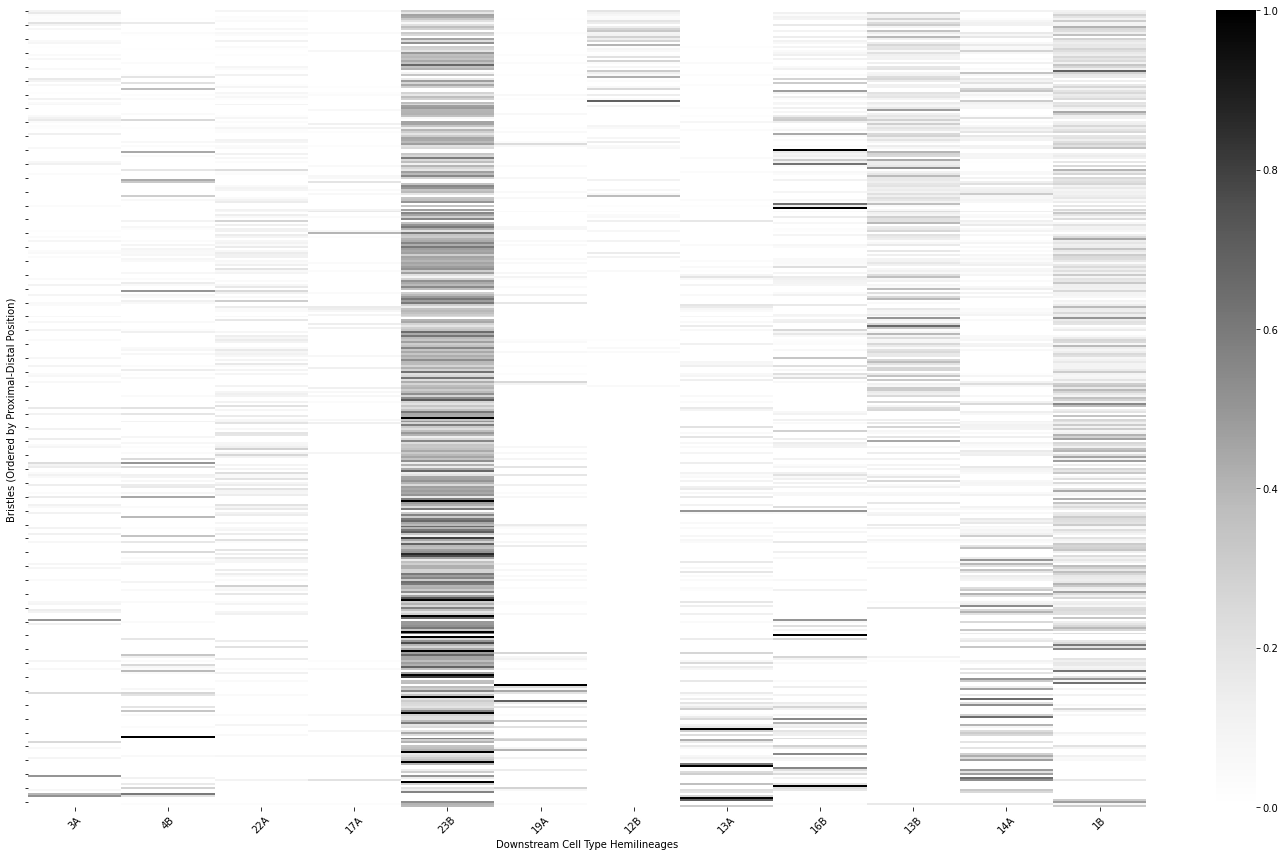

In [21]:

fig, ax = plt.subplots(figsize=(20,12)) #
data = heatmap_data.values.astype(float)
sns.heatmap(data,cmap='Greys',vmin=0,vmax=1.0)
ax.set_xticklabels(over_one, rotation=45)
ax.set_yticklabels([])
ax.set_ylabel('Bristles (Ordered by Proximal-Distal Position)')
ax.set_xlabel('Downstream Cell Type Hemilineages')
plt.tight_layout()

plt.show()

How does this map onto different neurotransmitters? We will now create a proportion output for each bristle neuron by inferring the neurotransmitter released of each hemilineage from previous work (Lacin 2019)

In [22]:
unstacked = edge_df.groupby(['pre_pt_root_id','neurotransmitter'])['synapse_count'].sum().unstack()
unstacked = unstacked.fillna(0)
unstacked = unstacked[['Cholinergic','GABA','Glutamatergic']]

fract_unstacked = unstacked.div(unstacked.sum(axis=1), axis=0)
pd_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_pd_avg))
ap_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_ap_binary))
dv_dict = dict(zip(bristle_df.pre_pt_root_id,bristle_df.bristle_dv_avg))
fract_unstacked['pd_pos'] = fract_unstacked.index.map(pd_dict)
fract_unstacked['ap_pos'] = fract_unstacked.index.map(ap_dict)
fract_unstacked['dv_pos'] = fract_unstacked.index.map(dv_dict)
fract_unstacked=fract_unstacked.sort_values(['pd_pos','ap_pos'])
fract_unstacked = fract_unstacked.reset_index()
fract_unstacked.head()

neurotransmitter,pre_pt_root_id,Cholinergic,GABA,Glutamatergic,pd_pos,ap_pos,dv_pos
0,648518346478700628,0.496403,0.359712,0.143885,4634.753693,0.0,14274.281784
1,648518346494807863,0.165680,0.337278,0.497041,4665.492052,0.0,8451.477721
2,648518346475417912,0.451777,0.477157,0.071066,4699.249251,0.0,9990.994894
3,648518346517939048,0.479452,0.410959,0.109589,4701.028451,0.0,10387.010381
4,648518346494673173,0.386207,0.453448,0.160345,4712.095576,0.0,10011.276792


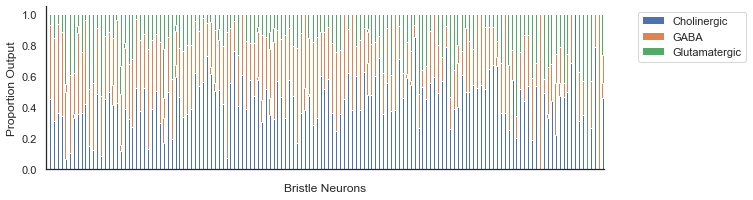

In [23]:
sns.set(style='white', font_scale =1)
fig, ax = plt.subplots(figsize=(10,2))
fract_unstacked[['Cholinergic','GABA','Glutamatergic']].plot(kind='bar',stacked=True,#cmap='tab20b',
                                                            figsize=(10,3),ax=ax, width = 1.1)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('Proportion Output')
ax.set_xlabel('Bristle Neurons')
ax.set_xticklabels([])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

How many cells of each cell-type are there downstream of all the bristle axons?

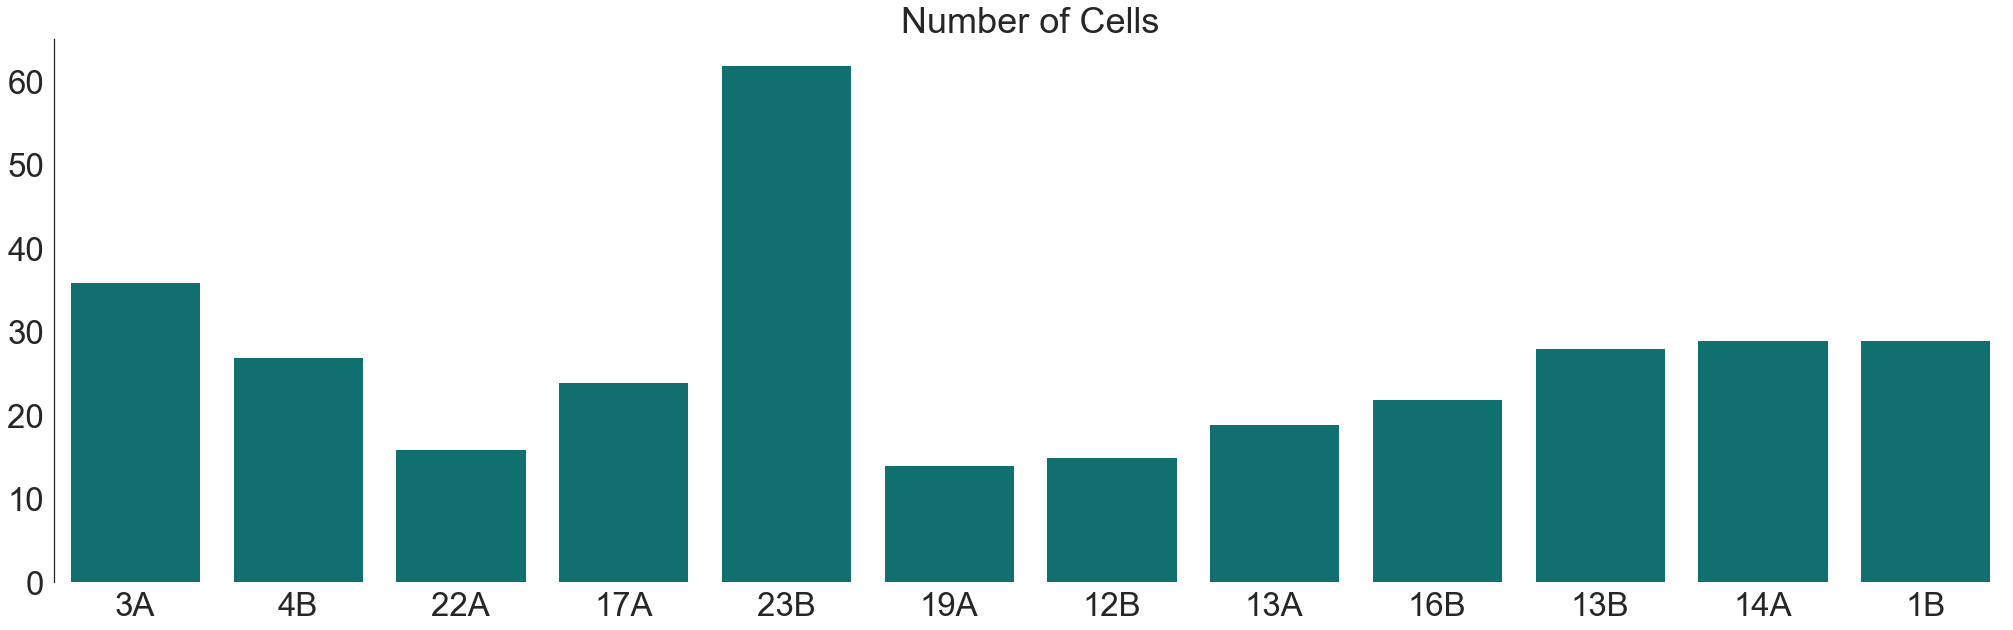

In [ ]:
#Filtering to only include the cell types that receive more than 1% of the output of bristles
# to make the plot easier to read
by_hemi = edge_df.query('post_cell_type in @over_one').groupby(['post_cell_type','post_pt_root_id']).size().reset_index(name='edge_count')
hemi_count_dict =  by_hemi.groupby('post_cell_type').size().to_dict()
hemis = edge_df.query('post_cell_type in @over_one').groupby('post_cell_type').post_pt_root_id.unique().keys()
all_counts = edge_df.query('post_cell_type in @over_one').groupby('post_cell_type').post_pt_root_id.unique().tolist()
hemi_counts = [hemi_count_dict[i] for i in over_one]


sns.set(style='white', font_scale =3)
fig, ax = plt.subplots(figsize=(35,10))
sns.barplot(x =over_one, y=hemi_counts,color='teal')
ax.set_title('Number of Cells')
plt.legend([], [], frameon=False)
#sns.despine(left=True, bottom=True)
sns.despine(bottom=True)
sns.set(rc={'figure.facecolor':(0,0,0,0)})


How many synapses do individual bristles make onto these different cell-types?

In [26]:
sum_df = edge_df.groupby(['bristle_pd_avg','bristle_ap_binary','bristle_dv_avg','post_cell_type']).sum()
sum_df = edge_df.groupby(['pre_pt_root_id','post_cell_type']).sum()
sum_dict = edge_df.groupby(['pre_pt_root_id'])['synapse_count'].sum().to_dict()

fracts = []
for ix,i in sum_df.iterrows():
    l = ix[0]
    count = i['synapse_count']
    fract = count/sum_dict[l]
    fracts.append(fract)
    
sum_df['fract_synapses'] = fracts

sum_df= sum_df.reset_index()


/Users/leilae/anaconda3/envs/flymoves/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


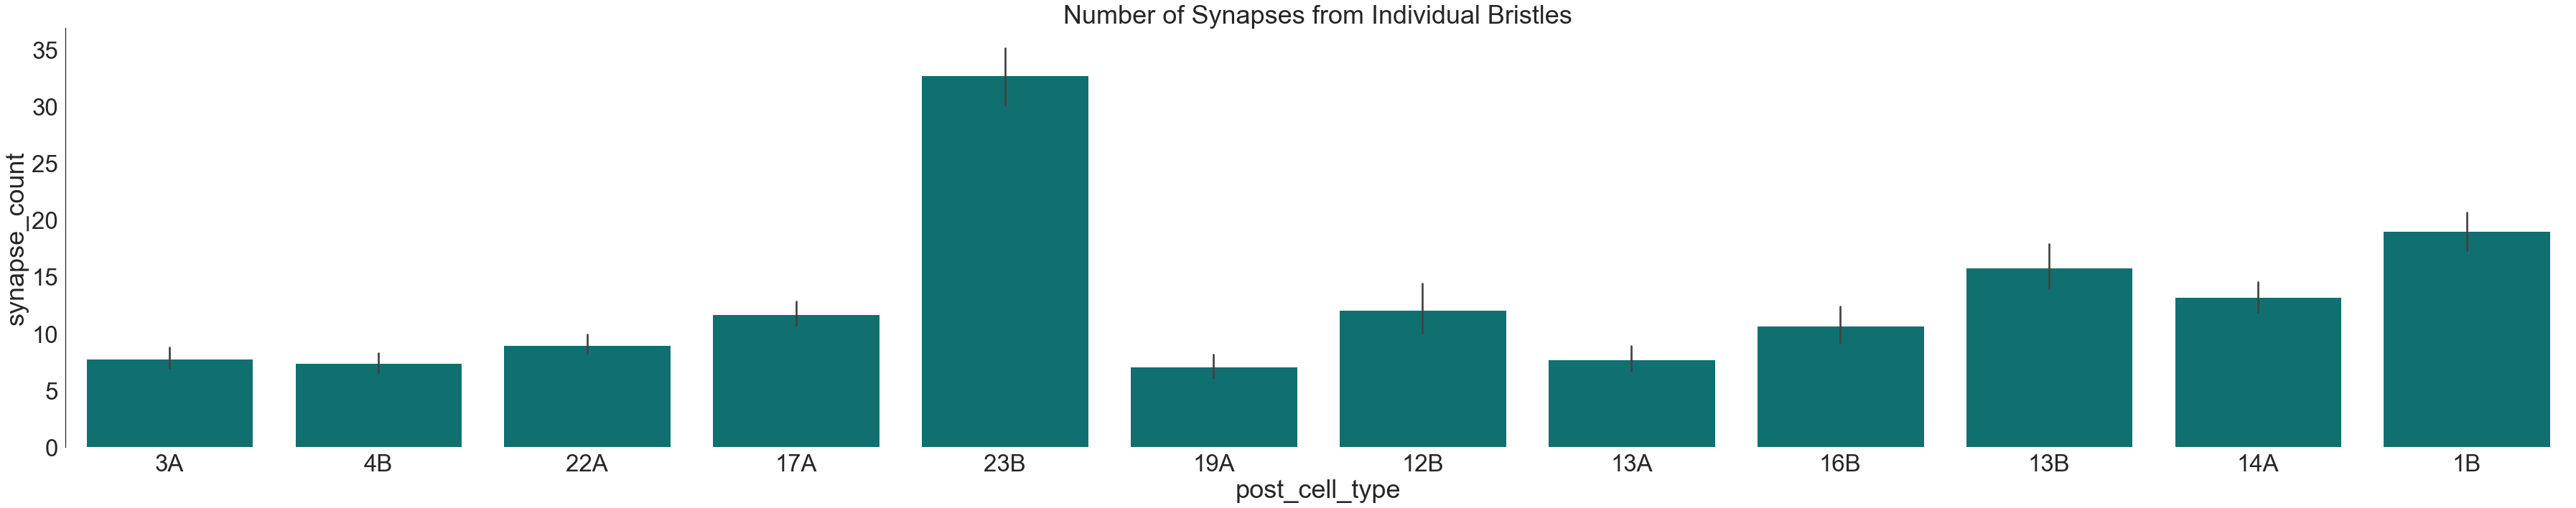

In [29]:
sns.set(style='white', font_scale =3)
fig, ax = plt.subplots(figsize=(50,10))

#Filtering to only include the cell types that receive more than 1% of the output of bristles
# to make the plot easier to read
plot_data = sum_df.query('post_cell_type in @over_one')
plot_data['post_cell_type'] = pd.Categorical(plot_data['post_cell_type'], categories=over_one, ordered=True)
plot_data = plot_data.sort_values('post_cell_type')
sns.barplot(x ='post_cell_type', y='synapse_count',color='teal',
                 data = plot_data)
ax.set_title('Number of Synapses from Individual Bristles') 
plt.legend([], [], frameon=False)
#sns.despine(left=True, bottom=True)
sns.despine(bottom=True)
sns.set(rc={'figure.facecolor':(0,0,0,0)})


plt.tight_layout()
plt.show()